Number of images in x_train: 60000
Number of images in x_test: 10000
Image width and height: 28 28


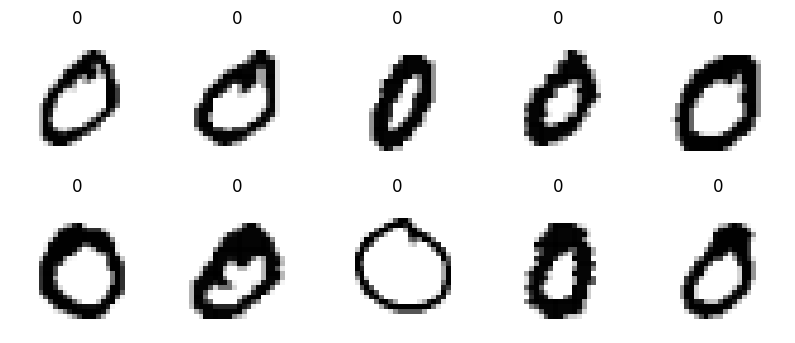

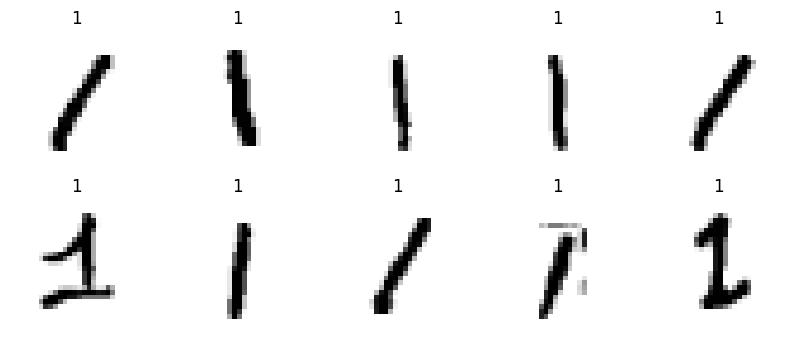

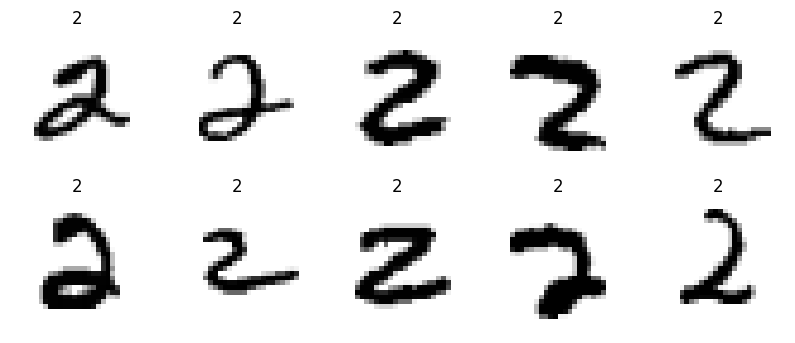

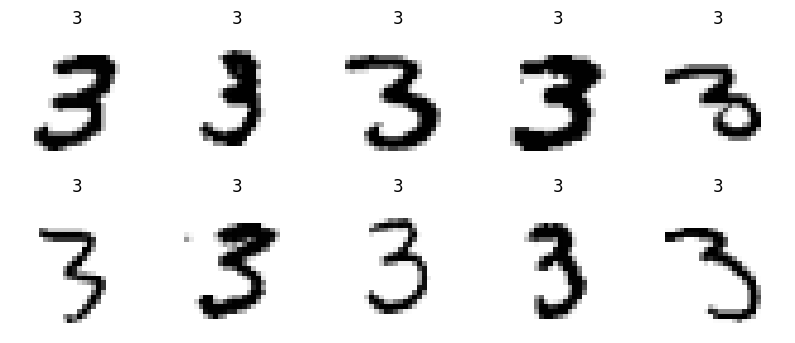

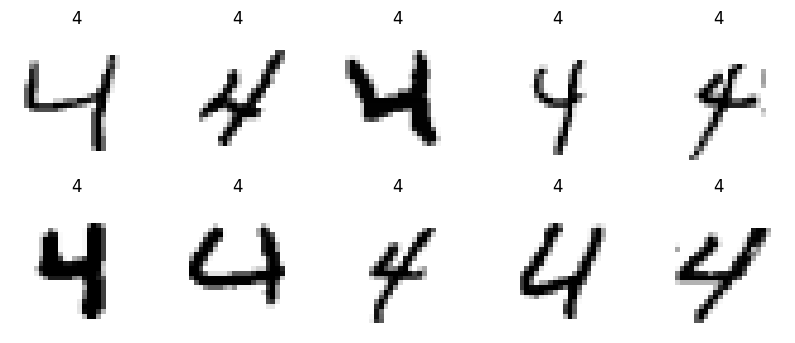

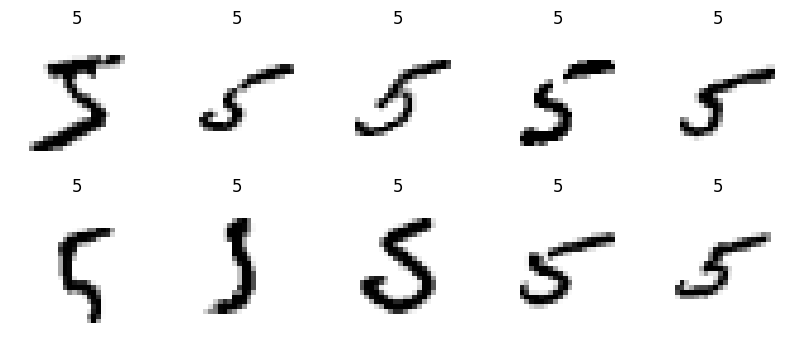

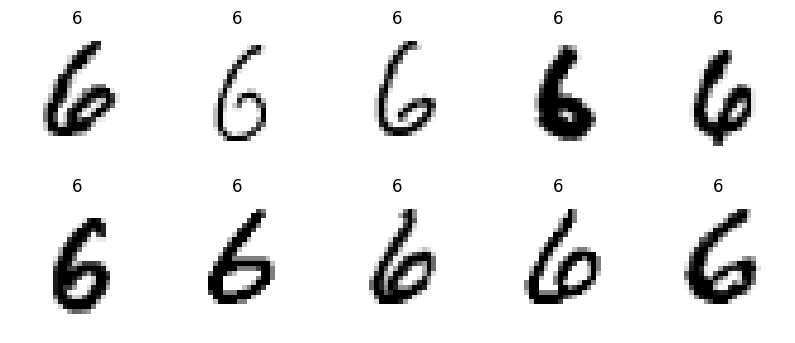

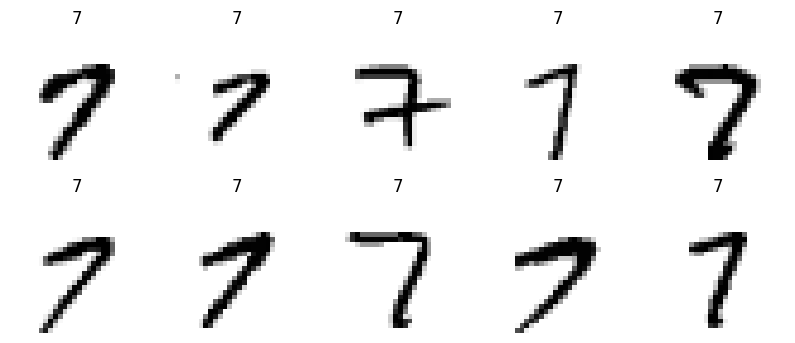

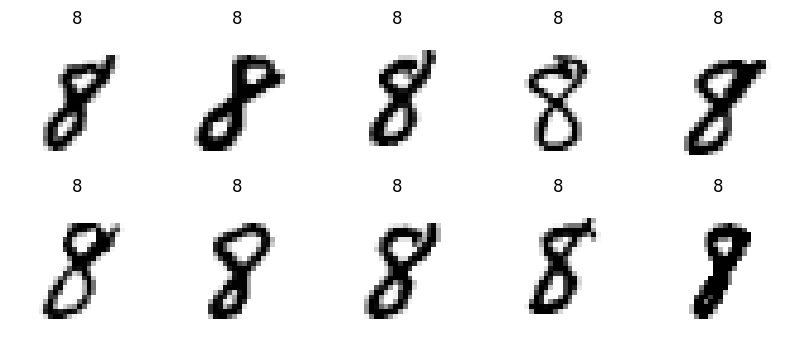

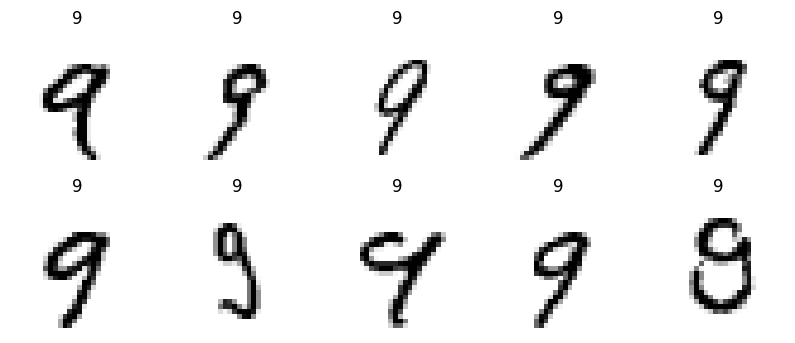

Number of images in x_train_01: 11274
Number of images in x_valid_01: 500
Number of images in x_test_01: 1954


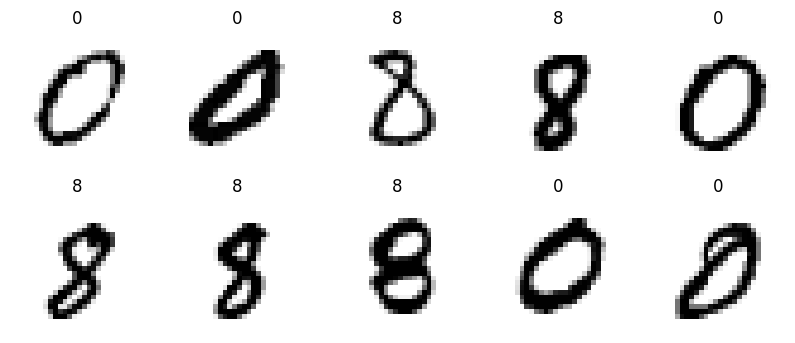

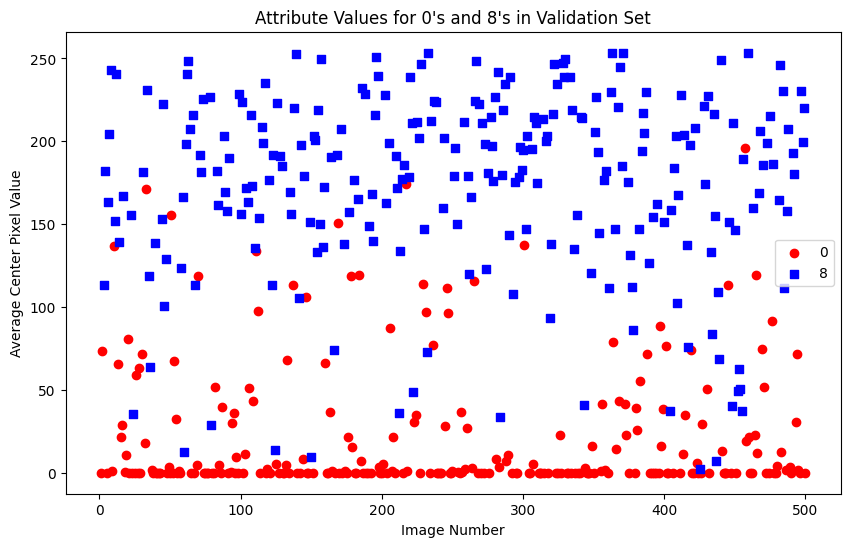

Threshold Guess: 100
Training Accuracy: 0.9385311335816924
Validation Accuracy: 0.914
Testing Accuracy: 0.9564994882292733


In [ ]:
# Assignment 4                   Noah Russell                           CAP4613
#import our libraries for our assignment
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

# Part (a)
(x_train, y_train), (x_test, y_test) = mnist.load_data() # loading mnist dataset (images, labels)
print("Number of images in x_train:", x_train.shape[0]) # print # of images in training set
print("Number of images in x_test:", x_test.shape[0]) # print # of images in testing set
print("Image width and height:", x_train.shape[1], x_train.shape[2]) # print image width and height (28 28)

# Part (b)
def plot_digits(images, labels): # our function take in images and labels for plotting
    fig, axes = plt.subplots(2, 5, figsize=(10, 4)) # create plot, axes, etc.
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i], cmap='binary') # display images in subplots
        ax.set_title(str(labels[i])) # set title of subplots to corresponding labels
        ax.axis('off') # remove axis lables
    plt.show() # display our figure

# Part (c)
for digit in range(10): # our loop to iterate over digits 0 to 9
    digit_indices = np.where(y_train == digit)[0][:10] # match labels to currrent digit
    plot_digits(x_train[digit_indices], y_train[digit_indices]) # plot first 10 images for each digit

# Part (d)
selected_digits = [0, 8] # selecting digits 0 to 8 as instructed
# storing images and labels below:
x_train_01 = x_train[np.isin(y_train, selected_digits)]
y_train_01 = y_train[np.isin(y_train, selected_digits)]
x_test_01 = x_test[np.isin(y_test, selected_digits)]
y_test_01 = y_test[np.isin(y_test, selected_digits)]

# Part (e)
validation_indices = np.random.choice(range(len(y_train_01)), size=500, replace=False) # randomly selecting 500 indices from training set
x_valid_01 = x_train_01[validation_indices] # storing selected images as validation set
y_valid_01 = y_train_01[validation_indices] # storing selected lables as validation set
x_train_01 = np.delete(x_train_01, validation_indices, axis=0) # remove selected images from training set
y_train_01 = np.delete(y_train_01, validation_indices, axis=0) # remove selected labels from training set

# Part (f)
print("Number of images in x_train_01:", x_train_01.shape[0]) # print training set
print("Number of images in x_valid_01:", x_valid_01.shape[0]) # print validation set (should be 500)
print("Number of images in x_test_01:", x_test_01.shape[0]) # print testing set

# Part (g)
plot_digits(x_valid_01[:10], y_valid_01[:10]) # using our function in part b to plot 10 images from validation set

# Part (h)
def calculate_average_center(grid_size, images): # function to calculate avg pixel value in center 4x4 grid of each img
    center_start = (images.shape[1] - grid_size) // 2
    center_end = center_start + grid_size
    center_values = images[:, center_start:center_end, center_start:center_end]
    return np.mean(center_values, axis=(1, 2)) # calculate average across center values of each image

center_attribute_train = calculate_average_center(4, x_train_01) # calculate center attribute for training set
center_attribute_valid = calculate_average_center(4, x_valid_01) # calculate center attribute for validation set
center_attribute_test = calculate_average_center(4, x_test_01) # calculate center attribute for testing set

# Part (i)
plt.figure(figsize=(10, 6)) # create scatter plot and set size

zeros_indices = np.where(y_valid_01 == 0)[0] # seperate 0's from 8's in validation set
eights_indices = np.where(y_valid_01 == 8)[0] # seperate 8's from 0's in validation set

plt.scatter(zeros_indices + 1, center_attribute_valid[zeros_indices], c='r', marker='o', label='0') # give 0's red color, circle marker, and label.
plt.scatter(eights_indices + 1, center_attribute_valid[eights_indices], c='b', marker='s', label='8') # give 8's blue color, square marker, and label.
plt.xlabel('Image Number') # plot x axis label
plt.ylabel('Average Center Pixel Value') # plot y axis label
plt.legend() # plot legend for out labels
plt.title('Attribute Values for 0\'s and 8\'s in Validation Set') # display title
plt.show() # display our plot

# Part (j)
threshold_guess = 100  # guessing our threshold based on the observed plot
print("Threshold Guess:", threshold_guess) # printing our guess

# Part (k)
train_predictions = center_attribute_train > threshold_guess # checks if our center attribute is greater than our threshold guess (for training set)
valid_predictions = center_attribute_valid > threshold_guess # checks if our center attribute is greater than our threshold guess (for validation set)
test_predictions = center_attribute_test > threshold_guess # checks if our center attribute is greater than our threshold guess (for testing set)

train_accuracy = np.mean(train_predictions == (y_train_01 == selected_digits[1])) # calculate training accuracy based on our threshold guess
valid_accuracy = np.mean(valid_predictions == (y_valid_01 == selected_digits[1])) # calculate validation accuracy based on our threshold guess
test_accuracy = np.mean(test_predictions == (y_test_01 == selected_digits[1])) # calculate testing accuracy based on our threshold guess

print("Training Accuracy:", train_accuracy) # printing training accuracy
print("Validation Accuracy:", valid_accuracy) # printing validation accuracy
print("Testing Accuracy:", test_accuracy) # printing testing accuracy